<a href="https://colab.research.google.com/github/ngjiamin2006/rsw2g5/blob/main/AI_Practical5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning: Supervised

## Supervised Learning

![](https://i163.photobucket.com/albums/t281/kyin_album/m1_1.png)

![](https://i163.photobucket.com/albums/t281/kyin_album/m6.png)

# <font color="blue"> Project 1: House Price Prediction

In this example, we'll use a linear regression model to predict housing prices based on 1 feature.

First, make sure you have scikit-learn installed. You can install it using pip:

In [21]:
!pip install scikit-learn
#prediction, classification... inside this kit

To know more about scikit-learn : [Scikit-learn Documentation](https://scikit-learn.org/stable/)

## Step 1: Prepare the data

In [22]:
# Importing necessary libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Sample dataset: housing prices (target) based on house size (feature)
house_sizes = np.array([550, 600, 650, 700, 750, 800, 850, 900, 950, 1000])
prices = np.array([300000, 410000, 530000, 510000, 540000, 610000, 730000, 760000, 830000, 860000])

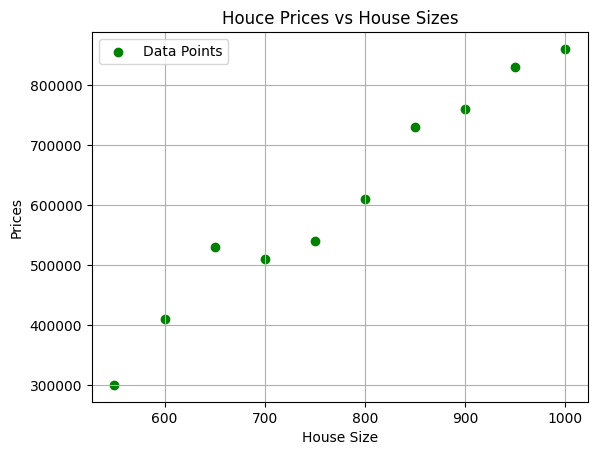

In [23]:
#plot graph prices against house_prices
import matplotlib.pyplot as plt

# Create a scatter plot
plt.scatter(house_sizes, prices, color='green', label='Data Points')
plt.xlabel('House Size')
plt.ylabel('Prices')
plt.title('Houce Prices vs House Sizes')
plt.legend()
plt.grid(True)
plt.show()

## Step 2 & 3 : Feature Extraction and Split the data (into training and testing set)

In [29]:
# Reshape the feature array to match the input format required by scikit-learn
X = house_sizes.reshape(-1,1)
print (X)

# Split the dataset into training and testing sets (80% train, 20% test)
X_train,X_test,y_train,y_test = train_test_split(X, prices, test_size=0.2, random_state=42)
print (X_test)
print (y_test)

[[ 550]
 [ 600]
 [ 650]
 [ 700]
 [ 750]
 [ 800]
 [ 850]
 [ 900]
 [ 950]
 [1000]]
[[950]
 [600]]
[830000 410000]


## Step 4: Fit model and predict outcomes [Code]

In [27]:
# Create the linear regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Formatting X_test
formatted_X_test = ["%.2f" % x for x in X_test]
print(formatted_X_test)

# Formatting y_pred
formatted_y_pred = ["%.2f" % y for y in y_pred]
print(formatted_y_pred)

['950.00', '600.00']
['813793.10', '396206.90']


/tmp/ipykernel_1590/2681384551.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  formatted_X_test = ["%.2f" % x for x in X_test]


In [28]:
# the following is the equation of the linear regression model

# Print the coefficients
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

# Construct the equation string
equation = f"y = {model.coef_[0]} * X + {model.intercept_}"
print("Linear Regression Equation:", equation)

Coefficient: [1193.10344828]
Intercept: -319655.1724137933
Linear Regression Equation: y = 1193.1034482758623 * X + -319655.1724137933


## Step 5: Evaluate the model [Code]

In [30]:
# Calculate the Mean Squared Error (MSE) as a measure of the model's performancemse = mean_squared_error(y_test, y_pred)
from sklearn.metrics import mean_squared_error
mse =  mean_squared_error(y_test, y_pred)


# Display the MSE with two decimal places using string formatting
formatted_mse = "%.2f" % mse
print(f"Mean Squared Error: {formatted_mse}")
#the lower error you get = highest result/good
#higher error = bad result

Mean Squared Error: 226456599.29


# Step 6: Predict unseen data

In [31]:
# Assuming you have a single unseen data point represented as a list
unseen_data = float(input("Enter house size: "))

# Reshape the unseen_data to a 2D array
unseen_data_reshaped = np.array(unseen_data).reshape(1, -1)

# Predict the target value for the unseen data point
predicted_value = model.predict(unseen_data_reshaped)

# Print the predicted value
print(f"Predicted Value (RM): {predicted_value[0]:.2f}")

Enter house size: 950
Predicted Value (RM): 813793.10


# Step 7 Store the model in Joblib

Store the model using joblib or pickle

In [32]:
from joblib import dump, load
#store inside joblib

In [33]:
dump(model, 'linear_regression_model.joblib')

['linear_regression_model.joblib']

Load the model and predict

In [ ]:
model = load('linear_regression_model.joblib')
user_input = int(input ("Enter house size:"))
input_array = np.array([user_input]).reshape(-1, 1)
predicted_price = model.predict(input_array)
print(f"Predicted Value: {predicted_price[0]:.2f}")

# Deployment

You can deploy into Streamlit or Flask.
Streamlit is an open-source app framework specifically designed for Machine Learning and Data Science projects. It allows data scientists and developers to create beautiful, interactive web apps quickly and with fewer lines of code. Streamlit’s simplicity and efficiency make it a popular choice for building data-driven web applications without the need for in-depth knowledge of web development frameworks.

Flask is a lightweight WSGI (Web Server Gateway Interface) web application framework. It is designed to make getting started with web application development quick and easy, with the ability to scale up to complex applications. Flask provides the tools, libraries, and technologies to build a web application. It allows developers to build web applications in Python, offering flexibility and choice in how the applications are built.

Follow instruction by tutor

1) Register Streamlit and link your github account

2) Create txt file name requirements, copy the following text into the txt file <br>
streamlit
joblib
numpy
scikit-learn

![Streamlitlogin](streamlitlogin.png)

3) Create another txt file and store the following Streamlit script and save as projectname.py e.g. linear_regression_house_price_prediction.py

In [ ]:
import streamlit as st
from joblib import load
import numpy as np

# Load the model
model = load('linear_regression_model.joblib')

# Create a simple user input
user_input = st.number_input('Enter house size:', min_value=100, max_value=10000, step=50)

# Reshape the input for the model
input_array = np.array([user_input]).reshape(-1, 1)

# Predict the house price
if st.button('Predict Price'):
    predicted_price = model.predict(input_array)
    st.write(f"The predicted house price is: ${predicted_price[0]:.2f}")

4) Upload the 2 files which are: requirements.txt and linear_regression_house_price_prediction.py into github and deploy using streamlit. Follow instruction from tutor.

# <font color="blue"> Project 2: House Price Prediction (2 features)

In the previous example, we used only one feature, which was the house size, to predict the house prices. This is called a univariate regression. To improve the model's performance, we can use multiple features, which is called a multivariate regression.

For instance, we can use additional features like the number of bedrooms, location, age of the house, etc., to make a more accurate prediction of the house prices. Using more relevant features often leads to better predictions.

Here's an example of how you can modify the previous code to use two features (house size and number of bedrooms) to predict house prices:

In [34]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Sample dataset: house sizes and number of bedrooms as features, and prices as the target variable
house_sizes = np.array([550, 600, 650, 700, 750, 800, 850, 900, 950, 1000])
num_bedrooms = np.array([2, 3,3 ,4 ,4 ,5 ,5 ,6 ,6 ,7 ])
prices = np.array([100000, 450000, 500000, 550000, 600000, 650000,700000 ,750000 ,800000 ,850000])

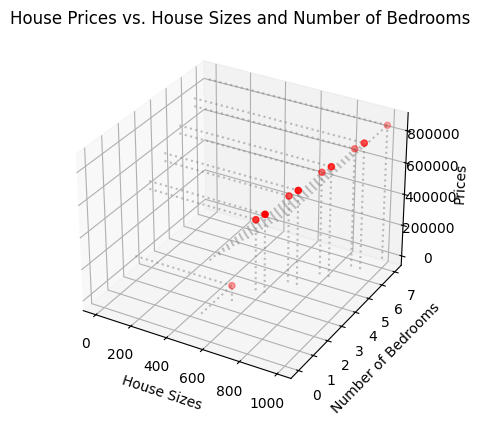

In [35]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# Create a 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Scatter plot points with house_sizes and num_bedrooms as X and Y, and prices as Z
ax.scatter(house_sizes, num_bedrooms, prices, c='r', marker='o')

# Labels for axes
ax.set_xlabel('House Sizes')
ax.set_ylabel('Number of Bedrooms')
ax.set_zlabel('Prices')

# Add dotted lines from data points to respective values on X and Y axes
for i in range(len(house_sizes)):
    ax.plot([house_sizes[i], house_sizes[i]], [num_bedrooms[i], num_bedrooms[i]], [0, prices[i]], c='gray', linestyle='dotted', alpha=0.5)
    ax.plot([house_sizes[i], house_sizes[i]], [0, num_bedrooms[i]], [prices[i], prices[i]], c='gray', linestyle='dotted', alpha=0.5)
    ax.plot([0, house_sizes[i]], [num_bedrooms[i], num_bedrooms[i]], [prices[i], prices[i]], c='gray', linestyle='dotted', alpha=0.5)

plt.title('House Prices vs. House Sizes and Number of Bedrooms')
plt.show()

In [38]:
from sklearn.metrics import mean_squared_error

# Combine the two features into a single feature matrix X
X = np.column_stack((house_sizes, num_bedrooms))
print("Feature matrix X:\n", X)

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test =  train_test_split(X, prices, test_size=0.2 , random_state=42)

# Create the linear regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Display the values with two decimal places using string formatting
formatted_X_test = np.array([["%.2f" % x[0], "%.2f" % x[1]] for x in X_test])
formatted_y_pred = ["%.2f" % y for y in y_pred]

print("Formatted X_test:")
print(formatted_X_test)

print("Formatted y_pred:")
print(formatted_y_pred)

# Compute and display Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
formatted_mse = "%.2f" % mse
print(f"Mean Squared Error: {formatted_mse}")

Feature matrix X:
 [[ 550    2]
 [ 600    3]
 [ 650    3]
 [ 700    4]
 [ 750    4]
 [ 800    5]
 [ 850    5]
 [ 900    6]
 [ 950    6]
 [1000    7]]
Formatted X_test:
[['950.00' '6.00']
 ['600.00' '3.00']]
Formatted y_pred:
['837500.00', '337500.00']
Mean Squared Error: 7031250000.00


In [39]:
house_size = float(input('Enter the house size (square feet): '))
num_bedrooms =  int(input("Enter the number of bedrooms: "))

# Create a feature array for the input
input_features = np.array([[house_size, num_bedrooms]])
print(input_features)

# Predict the price using the trained model
predicted_price = model.predict(input_features)[0]

# Display the predicted price
print(f"Predicted price for a house with size {house_size} sq ft and {num_bedrooms} bedrooms is (RM): {predicted_price:,.2f}")

Enter the house size (square feet): 10
Enter the number of bedrooms: 2
[[10.  2.]]
Predicted price for a house with size 10.0 sq ft and 2 bedrooms is (RM): -444,500.00


# <font color="blue"> Project 3: Spam Prediction

## Step 1: Prepare the data



In [ ]:
# make sure the data is labeled
import pandas as pd
data = pd.read_table('',encoding='windows-1252', header=None)              #complete this
data.columns = ['', '']          #complete this
print(data.head())
len(data)

In [ ]:
# remove words with numbers, punctuation and capital letters
import   #complete this
import   #complete this

alphanumeric = lambda x:        #complete this
punc_lower = lambda x:      #complete this

data['text'] = data.text.map(alphanumeric).map(punc_lower) #complete this
print(data.head())

## Step 2: Split the data (into training and testing set)

<Font color="Blue">__Input__: Features, Predictors, Independent Variables, X's
<Font color="orange">__Outputs__: Label, Outcome, Dependent Variable, Y
    
![](https://i163.photobucket.com/albums/t281/kyin_album/m2.png)

In [ ]:
# split the data into feature and label
X = data.     #complete this
y = data.    #complete this

In [ ]:
X.head()

In [ ]:
y.head()

## Overfitting

![](https://i163.photobucket.com/albums/t281/kyin_album/m3.png)

![](https://i163.photobucket.com/albums/t281/kyin_album/m4.png)

# Split the data [Code]

In [ ]:
# split the data into a training and test set
from sklearn.model_selection import            #complete this
X_train, X_test, y_train, y_test =             #complete this

# test size = 30% of observations, which means training size = 70% of observations
# random state = 42, so we all get the same random train / test split

In [ ]:
X_train.head()

In [ ]:
X_train.shape

In [ ]:
y_train.head()

In [ ]:
y_train.shape

In [ ]:
X_test.shape

In [ ]:
y_test.shape

## Step 3: Numerically encode the input data [Code]

In [ ]:
from                                               #complete this
cv = (stop_words='')                   #complete this
X_train_cv =                          #complete this
X_test_cv =                           #complete this

# print the dimensions of the training set (text messages, terms)
print(X_train_cv.toarray().shape)

In [ ]:
import joblib
joblib.dump(cv, 'countvectorizer.joblib')

In [ ]:
type(X_train_cv)
import scipy.sparse
pd.DataFrame.sparse.from_spmatrix(X_test_cv)

In [ ]:
help(cv.fit_transform)

## Step 4: Fit model and predict outcomes [Code]

In [ ]:
# Use a logistic regression model (categorical)
from sklearn.linear_model import    #complete this
lr =                               #complete this

# Train the model
lr.                             #complete this

# Take the model that was trained on the X_train_cv data and apply it to the X_test_cv
y_pred_cv = lr.                 #complete this
y_pred_cv

In [ ]:
joblib.dump(lr, 'logistic_regression_model.joblib')

## Step 5: Evaluate the model

![](https://i163.photobucket.com/albums/t281/kyin_album/m5.png)

# Step 5: Evaluate the model [Code]

In [ ]:
from sklearn.metrics import confusion_matrix  #complete this
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#Provided you are running IPython, the %matplotlib inline will make your plot outputs appear and be stored within the notebook
cm = confusion_matrix(y_test, y_pred_cv)   #y_test is the label of testing data, y_pred_cv is the predicted ans from the ML with testing set
print(cm[0])
print(cm[1])
sns.heatmap(cm, xticklabels=['predicted_ham', 'predicted_spam'], yticklabels=['actual_ham', 'actual_spam'], annot=True, fmt='d', annot_kws={'fontsize':20}, cmap="YlGnBu");
true_neg, false_pos = cm[0]
false_neg, true_pos = cm[1]

accuracy = round((true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg),3)
precision = round((true_pos) / (true_pos + false_pos),3)
recall = round((true_pos) / (true_pos + false_neg),3)
f1 = round(2 * (precision * recall) / (precision + recall),3)
print('Accuracy: {}'.format(accuracy))
print('Precision: {}'.format(precision))
print('Recall: {}'.format(recall))
print('F1 Score: {}'.format(f1))

## Step 6: Predict new input [Code]

In [ ]:
import pandas as pd
from pandas import                     #complete this
Sentence1 = ["Free entry in 2 a wkly comp to win FA Cup final tkts 21st"]

Snew = cv.                      #complete this
result = lr.                       #complete this

print(result)

# <font color="blue"> __Naive Bayes__

# Naive Bayes [code]

In [ ]:
# Use a Naive Bayes model
from sklearn.naive_bayes import         #complete this
import numpy as np
nb = MultinomialNB()

# Train the model
                           #complete this

# Take the model that was trained on the X_train_cv data and apply it to the X_test_cv
                           #complete this



# Naive Bayes: Results

In [ ]:
cm = confusion_matrix(y_test, y_pred_cv_nb)
sns.heatmap(cm, xticklabels=['predicted_ham', 'predicted_spam'], yticklabels=['actual_ham', 'actual_spam'],
annot=True, fmt='d', annot_kws={'fontsize':20}, cmap="YlGnBu");
true_neg, false_pos = cm[0]
false_neg, true_pos = cm[1]
accuracy = round((true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg),3)
precision = round((true_pos) / (true_pos + false_pos),3)
recall = round((true_pos) / (true_pos + false_neg),3)
f1 = round(2 * (precision * recall) / (precision + recall),3)
print('Accuracy: {}'.format(accuracy))
print('Precision: {}'.format(precision))
print('Recall: {}'.format(recall))
print('F1 Score: {}'.format(f1))

NBscore = nb.score(X_test_cv, y_test)

# <font color="blue"> Project 4: Review Rating Prediction

In [ ]:
import nltk
import pandas as pd

In [ ]:
data = pd.read_csv('')
data.head()

# Question 1

- Determine how many reviews there are in total.


Use the preprocessing code below to clean the reviews data before moving on to modeling.


In [ ]:
# Text preprocessing steps - remove numbers, captial letters and punctuation
import re
import string

alphanumeric =          #complete this
punc_lower =            #complete this

data.head()

In [ ]:
type(data)

# Question 2: Classsification *(20% testing, 80% training)*

Processes for classification

### <font color="Blue">Step 1:</font> Prepare the data (identify the feature and label)

In [ ]:
# split the data into feature and label
X = data.                  #complete this
y = data.                   #complete this

X.head()

### <font color="Blue">Step 2:</font> Split the data into training and testing sets

In [ ]:
# split the data into a training and test set
from sklearn.model_selection import                    #complete this
X_train, X_test, y_train, y_test =                      #complete this

In [ ]:
X_test.head()

In [ ]:
y_test.head()

### <font color="Blue">Step 3:</font> Vectorize the feature

In [ ]:
from sklearn.feature_extraction.text import              #complete this
cv = CountVectorizer(stop_words='')                       #complete this
X_train_cv =                                                 #complete this
X_test_cv =                                                #complete this

# print the dimensions of the training set (text messages, terms)
print(X_train_cv.toarray().shape)

### <font color="Blue">Step 4:</font> Idenfity the model/ classifier to be used. Feed the train data into the model

### - Linear Regression

In [ ]:
# Use a linear regression model
from sklearn.linear_model import      #complete this
lr = LinearRegression()

# Train the model
                    #complete this

# Take the model that was trained on the X_train_cv data and apply it to the X_test_cv
                   #complete this


In [ ]:
# Use a logistic regression model
from sklearn.linear_model import                  #complete this
lr = LogisticRegression()

# Train the model
                   #complete this

# Take the model that was trained on the X_train_cv data and apply it to the X_test_cv
                   #complete this

### - SVM

In [ ]:
from sklearn.svm import              #complete this
svc = LinearSVC()

# Train the model
              #complete this

# Take the model that was trained on the X_train_cv data and apply it to the X_test_cv
               #complete this


### - Decision Tree

In [ ]:
from sklearn import                       #complete this
tree = tree.DecisionTreeClassifier()

# Train the model
                     #complete this

# Take the model that was trained on the X_train_cv data and apply it to the X_test_cv
                 #complete this

### - Random Forest

In [ ]:
from sklearn.ensemble import      #complete this
forest = RandomForestClassifier(max_depth=10, random_state=0)

# Train the model
                      #complete this                  #complete this

# Take the model that was trained on the X_train_cv data and apply it to the X_test_cv
                  #complete this

### - KNN

In [ ]:
from sklearn.neighbors import                 #complete this
neigh = KNeighborsClassifier(n_neighbors=3)

# Train the model
  #complete this

# Take the model that was trained on the X_train_cv data and apply it to the X_test_cv
  #complete this

### -  Naive Bayes

In [ ]:
from sklearn.naive_bayes import  #complete this
import numpy as np
nb = MultinomialNB()

# Train the model
#complete this

# Take the model that was trained on the X_train_cv data and apply it to the X_test_cv
#complete this

### <font color="Blue">Step 5:</font> Evaluate the Model - Accuracy Measurement
Generate the accuracy scores for Linear Regression, SVM, Decision Tree, Random Forest, KNN, and Naive Bayes.  

In [ ]:
from sklearn.metrics import                   #complete this
lra = accuracy_score(y_test, y_pred_LR)
svm = accuracy_score(y_test, y_pred_svm)
dt = accuracy_score(y_test, y_pred_dt)
rf = accuracy_score(y_test, y_pred_rf)
knn = accuracy_score(y_test, y_pred_knn)
nb = accuracy_score(y_test, y_pred_nb)

print("Accuracy score for LR: %.2f" % lra)
print("Accuracy score for SVM: %.2f" % svm)
print("Accuracy score for DT: %.2f" % dt)
print("Accuracy score for RF: %.2f" % rf)
print("Accuracy score for KNN: %.2f" % knn)
print("Accuracy score for NB: %.2f" % nb)

__Example Output:__
- Accuracy score for LR  = 0.1651
- Accuracy score for SVM = 0.5413
- Accuracy score for DT  = 0.5505
- Accuracy score for RF  = 0.5872
- Accuracy score for KNN = 0.5963
- Accuracy score for NB  = 0.6514

# Question 3
Predict the rate of this review,

<font color="blue">__"like Cafe Vienna instant coffee products with the convenience of Keurig. All authorized on-line sellers cannot carry them"__



by using Linear Regression, SVM, Decision Tree, Random Forest, KNN, and Naive Bayes

In [ ]:
import pandas as pd
from pandas import DataFrame
# S0 = ["I dislike this coffee, terrible taste and very greasy."]
# S1 = ["This has to be the worst tasting coffee.this is the by far the worst. Don't waste your money on this product."]
S2 = ["like Cafe Vienna instant coffee products with the convenience of Keurig. All authorized on-line sellers cannot carry them "]

Snew = cv.transform(S2)
lry = lr.predict(Snew)
print(lry)

In [ ]:
import pandas as pd
from pandas import DataFrame

# Take user input
user_input =                               #complete this

Snew = cv.                                #complete this
lry = lr.                                #complete this
print("Predicted Label:", lry[0])